# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [74]:
'''
Reasearch question: Can we train machine learning models to predict the future performance of a webpage using past data about that webpage?
Can this model also identify which webpage will likely become worse for each of the metrics (clicks, impression, position)?
It supports the decision of resource allocation and prioritizing which pages humans should review and update.
'''

'\nReasearch question: Can we train machine learning models to predict the future performance of a webpage using past data about that webpage?\nCan this model also identify which webpage will likely become worse for each of the metrics (clicks, impression, position)?\nIt supports the decision of resource allocation and prioritizing which pages humans should review and update.\n'

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [75]:
'''
I used the tables fact_content_daily_performance and dim_content. 
fact_content_daily_performance includes how many clicks, impressions, and position each page received on each day.
dim_content includes some general information about each page, of which I used word_count, update_date, create_date, main_intent.
I used date windows of 90 consecutive days for each row where data is available for all 90 days in fact_content_daily_performance.
I included only date windows after the last update date to guarantee that no update occurred during the middle of a window.
The date window is split into days 1-15, days 16-30, days 31-45, days 46-60 (features), and days 61-90 (target).
I excluded the tables dim_clients and fact_content_query_90d because the model is predicting the performance of a page, not a client or query.
I excluded some columns in dim_clients (search_volume, backlinks, etc) because it was not stated which date these date comes from,
so including them might risk leakage of future data not available at inference time.
'''

'\nI used the tables fact_content_daily_performance and dim_content. \nfact_content_daily_performance includes how many clicks, impressions, and position each page received on each day.\ndim_content includes some general information about each page, of which I used word_count, update_date, create_date, main_intent.\nI used date windows of 90 consecutive days for each row where data is available for all 90 days in fact_content_daily_performance.\nI included only date windows after the last update date to guarantee that no update occurred during the middle of a window.\nThe date window is split into days 1-15, days 16-30, days 31-45, days 46-60 (features), and days 61-90 (target).\nI excluded the tables dim_clients and fact_content_query_90d because the model is predicting the performance of a page, not a client or query.\nI excluded some columns in dim_clients (search_volume, backlinks, etc) because it was not stated which date these date comes from,\nso including them might risk leakag

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [76]:
'''
Assumptions: recent performance of a page contains useful information about near term future performance 
if the page was not updated during the window.
Features: clicks_1_15, clicks_16_30, clicks_31_45, clicks_46_60, impressions_1_15, impressions_16_30, impressions_31_45, impressions_46_60, 
position_1_15, position_16_30, position_31_45, position_46_60, word_count, update_date, create_date, and main_intent.
Label definitions: clicks_61_90 = total # of clicks in the last 30 days of the window, 
impressions_61_90 = total # of impressions in the last 30 days, and position_61_90 = avg position in the last 30 days.
Baselines: 1. Values from the last 15 days, it will be doubled for clicks and impressions. 
2. The average values from the 60 days, it will be doubled for clicks and impressions and weighted by impressions for position.
3. Flag the page if it decreases at least 15% for clicks and impressions and increases at least 15% for position.
Validation design: the data is split into 80% of rows for train and 10% each for val and test. Each page belongs to only 1 split.
The val split is used to choose the hyperparameters for HistGradientBoostingRegressor while test split is used for the final result.
Leakage checks: Clicks, impressions, and position are from the past (days 1-60), not the future (days 61-90). Create_date is definitely past.
update_date, word_count, and main_intent cannot be changed unless page is updated, and all windows start after the last update date.
Because the splits are page disjoint, the pages in train split cannot leak info about pages in test split.
'''

'\nAssumptions: recent performance of a page contains useful information about near term future performance \nif the page was not updated during the window.\nFeatures: clicks_1_15, clicks_16_30, clicks_31_45, clicks_46_60, impressions_1_15, impressions_16_30, impressions_31_45, impressions_46_60, \nposition_1_15, position_16_30, position_31_45, position_46_60, word_count, update_date, create_date, and main_intent.\nLabel definitions: clicks_61_90 = total # of clicks in the last 30 days of the window, \nimpressions_61_90 = total # of impressions in the last 30 days, and position_61_90 = avg position in the last 30 days.\nBaselines: 1. Values from the last 15 days, it will be doubled for clicks and impressions. \n2. The average values from the 60 days, it will be doubled for clicks and impressions and weighted by impressions for position.\n3. Flag the page if it decreases at least 15% for clicks and impressions and increases at least 15% for position.\nValidation design: the data is spli

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [ ]:
'''
Clicks recent 15 day baseline: Mean absolute error = 2.8983957219251337, R2 score = 0.8162570699245038
Clicks mean 60 day baseline: Mean absolute error = 2.825668449197861, R2 score = 0.7866514920037863
Clicks model performance: Mean absolute error = 2.4021781561785294, R2 score = 0.8863866603138656

Impressions recent 15 day baseline: Mean absolute error = 743.9522281639929, R2 score = 0.7633164192420292
Impressions mean 60 day baseline: Mean absolute error = 1090.2247771836007, R2 score = 0.7057075017721606
Impressions model performance: Mean absolute error = 603.9551392278299, R2 score = 0.8734313180224106

Position recent 15 day baseline: Mean absolute error = 4.92981701679662, R2 score = 0.7336817334283864
Position mean 60 day baseline: Mean absolute error = 6.073677285624553, R2 score = 0.6226871089824088
Position model performance: Mean absolute error = 3.759330180284617, R2 score = 0.8483991611488413

Flags:
Model precision (flagged pages that decreased, or increased for position, at least 10%):
Clicks = 0.7053763440860215, Impressions = 0.8279883381924198, Position = 0.7881987577639752
Baseline precision: 
Clicks = 0.48265368228849664, Impressions = 0.9251533742331288, Position = 0.5746753246753247
'''

## 5. Limitations

*What this work cannot claim.*

In [ ]:
'''
It does not say what is the reason or establish causal relationships for its predicted values for clicks, impressions, or position.
It tends to overestimate smaller values and underestimate larger values for each metric, so it is less accurate for extreme values.
The model is both trained and tested on Flyrank's dataset, so it may not generalize to all pages.
The model does not know if there is a festive season in the recent past or near future that could cause the metrics to be very high.
For flagging pages that will decline in impressions, the model performs worse than a simple baseline.
'''

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [52]:
import pandas as pd
import csv
df = pd.read_csv('work/outputs/result.csv')
headers = ['priority', 'result_csv_id', 'reason_codes', 'pred_clicks', 'pred_impressions', 'pred_position', 
          'true_clicks', 'true_impressions', 'true_position']
data = []
for i in range(len(df)):
    row = df.iloc[i]
    reason_codes = ''
    priority = 0
    if int(row['clicks_decline']) == 1: 
        reason_codes += 'clicks_decline'
        priority += 1
    if int(row['impressions_decline']) == 1: 
        reason_codes += (';' if reason_codes else '') + 'impressions_decline'
        priority += 1
    if int(row['position_worsen']) == 1: 
        reason_codes += (';' if reason_codes else '') + 'position_worsen'
        priority += 1
    data.append([priority, i, reason_codes, row['pred_clicks'], row['pred_impressions'], row['pred_position'],
                row['true_clicks'], row['true_impressions'], row['true_position']])
data.sort(reverse=True)
with open('work/outputs/action_playbook.csv', mode='w', newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(headers)
    writer.writerows(data)

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

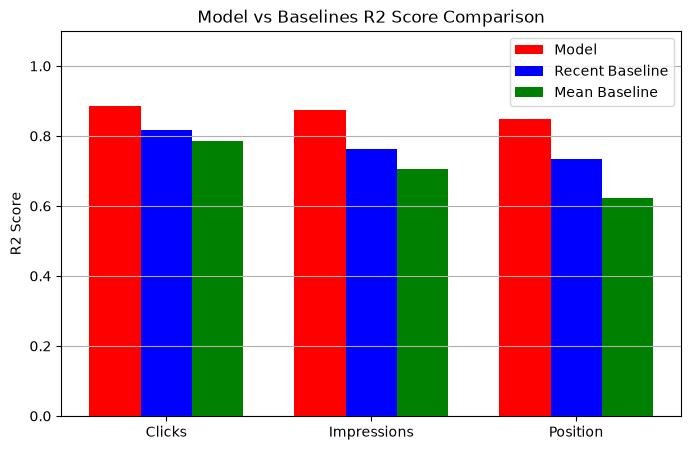

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
categories = ['Clicks', 'Impressions', 'Position']
model = [0.8863866603138656, 0.8734313180224106, 0.8483991611488413]
baseline1 = [0.8162570699245038, 0.7633164192420292, 0.7336817334283864]
baseline2 = [0.7866514920037863, 0.7057075017721606, 0.6226871089824088]
x = np.arange(len(categories))
width = 0.25
plt.figure(figsize=(8, 5))
plt.bar(x - width, model, width, label='Model', color='red')
plt.bar(x, baseline1, width, label='Recent Baseline', color='blue')
plt.bar(x + width, baseline2, width, label='Mean Baseline', color='green')
plt.ylabel('R2 Score')
plt.title('Model vs Baselines R2 Score Comparison')
plt.xticks(x, categories)
plt.legend()
plt.grid(axis='y')
plt.ylim(0, 1.1)
plt.show()


In [72]:
table = pd.DataFrame({
"Target": ["Clicks", "Impressions", "Position"],
    "Model MAE": [2.402, 603.955, 3.759],
    "Recent Baseline MAE": [2.845, 723.456, 4.123],
    "Mean Baseline MAE": [2.826, 1090.225, 6.074],
})
table.head()

,Target,Model MAE,Recent Baseline MAE,Mean Baseline MAE
0,Clicks,2.402,2.845,2.826
1,Impressions,603.955,723.456,1090.225
2,Position,3.759,4.123,6.074


/var/folders/_b/yynhlh9s339c2gvwx12flcqm0000gp/T/ipykernel_72496/1077591183.py:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


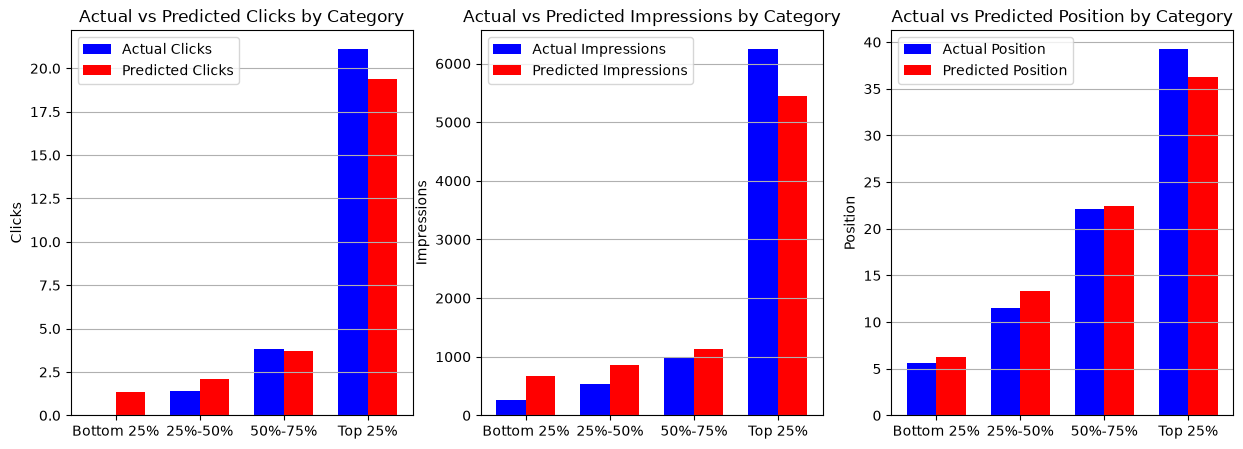

In [66]:
categories = ['Bottom 25%', '25%-50%', '50%-75%', 'Top 25%']
clicks_actual = [0, 1.39, 3.81, 21.13]
clicks_predicted = [1.36, 2.10, 3.72, 19.40]
impressions_actual = [267.97, 540.95, 1001.61, 6252.26]
impressions_predicted = [665.56, 855.55, 1140.32, 5442.40]
position_actual = [5.59, 11.52, 22.14, 39.29]
position_predicted = [6.30, 13.32, 22.40, 36.21]
x = np.arange(len(categories))
width = 0.35
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
ax1.bar(x - width/2, clicks_actual, width, label='Actual Clicks', color='blue')
ax1.bar(x + width/2, clicks_predicted, width, label='Predicted Clicks', color='red')
ax1.set_ylabel('Clicks')
ax1.set_title('Actual vs Predicted Clicks by Category')
ax1.set_xticks(x)
ax1.set_xticklabels(categories)
ax1.legend()
ax1.grid(axis='y')
ax2.bar(x - width/2, impressions_actual, width, label='Actual Impressions', color='blue')
ax2.bar(x + width/2, impressions_predicted, width, label='Predicted Impressions', color='red')
ax2.set_ylabel('Impressions')
ax2.set_title('Actual vs Predicted Impressions by Category')
ax2.set_xticks(x)
ax2.set_xticklabels(categories)
ax2.legend()
ax2.grid(axis='y')
ax3.bar(x - width/2, position_actual, width, label='Actual Position', color='blue')
ax3.bar(x + width/2, position_predicted, width, label='Predicted Position', color='red')
ax3.set_ylabel('Position')
ax3.set_title('Actual vs Predicted Position by Category')
ax3.set_xticks(x)
ax3.set_xticklabels(categories)
ax3.legend()
ax3.grid(axis='y')
fig.show()

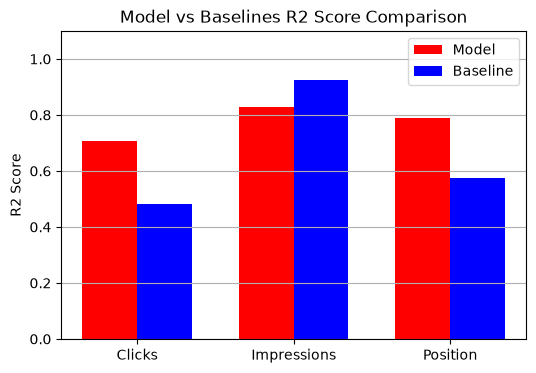

In [71]:
categories = ['Clicks', 'Impressions', 'Position']
model = [0.7053763440860215, 0.8279883381924198, 0.7881987577639752]
baseline = [0.48265368228849664, 0.9251533742331288, 0.5746753246753247]
x = np.arange(len(categories))
width = 0.35
plt.figure(figsize=(6, 4))
plt.bar(x - width/2, model, width, label='Model', color='red')
plt.bar(x + width/2, baseline, width, label='Baseline', color='blue')
plt.ylabel('R2 Score')
plt.title('Model vs Baselines R2 Score Comparison')
plt.xticks(x, categories)
plt.legend()
plt.grid(axis='y')
plt.ylim(0, 1.1)
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.